In [41]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split , cross_val_score
from sklearn.tree import DecisionTreeClassifier , plot_tree  
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
df = pd.read_csv("loan_approval.csv")


In [8]:
print(df.shape)
df.head()

(3000, 7)


,age,income,credit_score,debt_ratio,num_loans,employed,approved
0,24,114096,688,0.757,0,0,0
1,55,63205,724,0.169,3,1,1
2,49,60412,843,0.161,0,0,1
3,40,95669,759,0.206,0,1,1
4,40,115122,558,0.335,2,0,1


In [9]:
print(df['approved'].value_counts().to_dict())

{1: 1866, 0: 1134}


In [10]:
X = df.drop(columns=['approved']); y = df['approved']
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, stratify=y)

## TASK 01 - Grow an unpruned tree and prove it overfits

#### Fit a DecisionTreeClassifier(random_state=42) with no constraints on the training data.

#### Print depth and leaf count, and record train accuracy vs test accuracy side by side.

#### State in one line why the gap you see is the definition of overfitting.

In [12]:
tree = DecisionTreeClassifier(random_state=42).fit(X_train, y_train)
print('Tree Depth:',tree.get_depth(),'Numbers of Leaves:', tree.get_n_leaves())
print('train', tree.score(X_train, y_train))
print('test ', tree.score(X_test, y_test))

Tree Depth: 22 Numbers of Leaves: 432
train 1.0
test  0.7293333333333333


##### **==> The tree is overfitted because it uses every single noise in the tree .while training but at the new data given in the testing it doesnot perfect well because it learns the noise which is not important and it gives less accuracy in the test data**

## TASK 02 - Sweep max_depth and find the sweet spot

#### For max_depth in 1..15, fit a tree (min_samples_leaf=5, random_state=42) on X_train and record both train and test accuracy.

#### Plot both curves on one chart (train vs test vs depth). Label them.

#### Pick the depth where test accuracy is highest and print it.

best depth 3


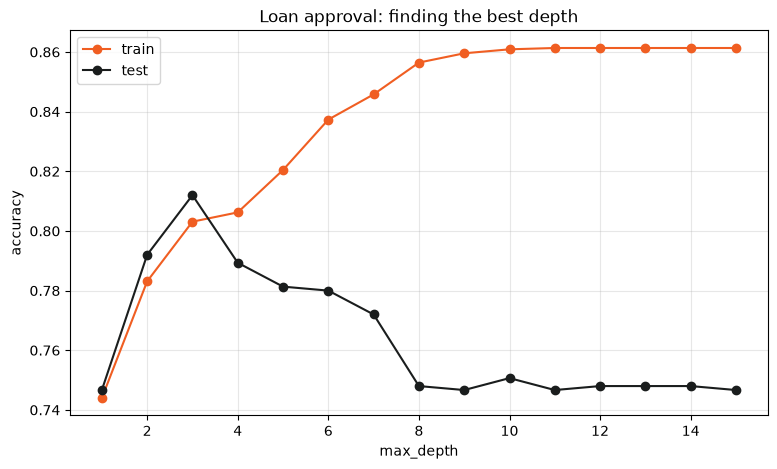

best depth: 3


In [21]:
depths = list(range(1,16))
tr_s, te_s = [], []
for d in depths:
    c = DecisionTreeClassifier(max_depth=d, min_samples_leaf=8, random_state=7)
    c.fit(X_train, y_train)
    tr_s.append(c.score(X_train, y_train))
    te_s.append(c.score(X_test, y_test  ))

best = depths[te_s.index(max(te_s))]; print('best depth', best)

plt.figure(figsize=(9, 5))
plt.plot(depths, tr_s, "o-", label="train", color="#F05E22")
plt.plot(depths, te_s, "o-", label="test",  color="#1A1D1D")
plt.xlabel("max_depth"); plt.ylabel("accuracy")
plt.title("Loan approval: finding the best depth"); plt.legend(); plt.grid(alpha=0.3)
plt.show()

print('best depth:' , best)

In [35]:
best_d = depths[int(np.argmax(te_s))]
best = DecisionTreeClassifier(max_depth=best_d, min_samples_leaf=8, random_state=7)
best.fit(X_train, y_train)
print(f"best depth picked from the curve: {best_d}")
print(f"train accuracy: {best.score(X_train, y_train):.3f}")
print(f"test accuracy : {best.score(X_test, y_test):.3f}")



best depth picked from the curve: 3
train accuracy: 0.803
test accuracy : 0.812


## TASK 03 - Draw the tree and read it as rules

#### Fit a pruned tree (max_depth=4, min_samples_leaf=5, random_state=42).

#### Draw it with plot_tree(..., filled=True, rounded=True, feature_names=X.columns).

#### Write out the top 3 rules as plain English / Hindi if-then sentences you could explain to your grandmother.

depth: 4, leaves: 16
train accuracy: 0.806
test accuracy : 0.789


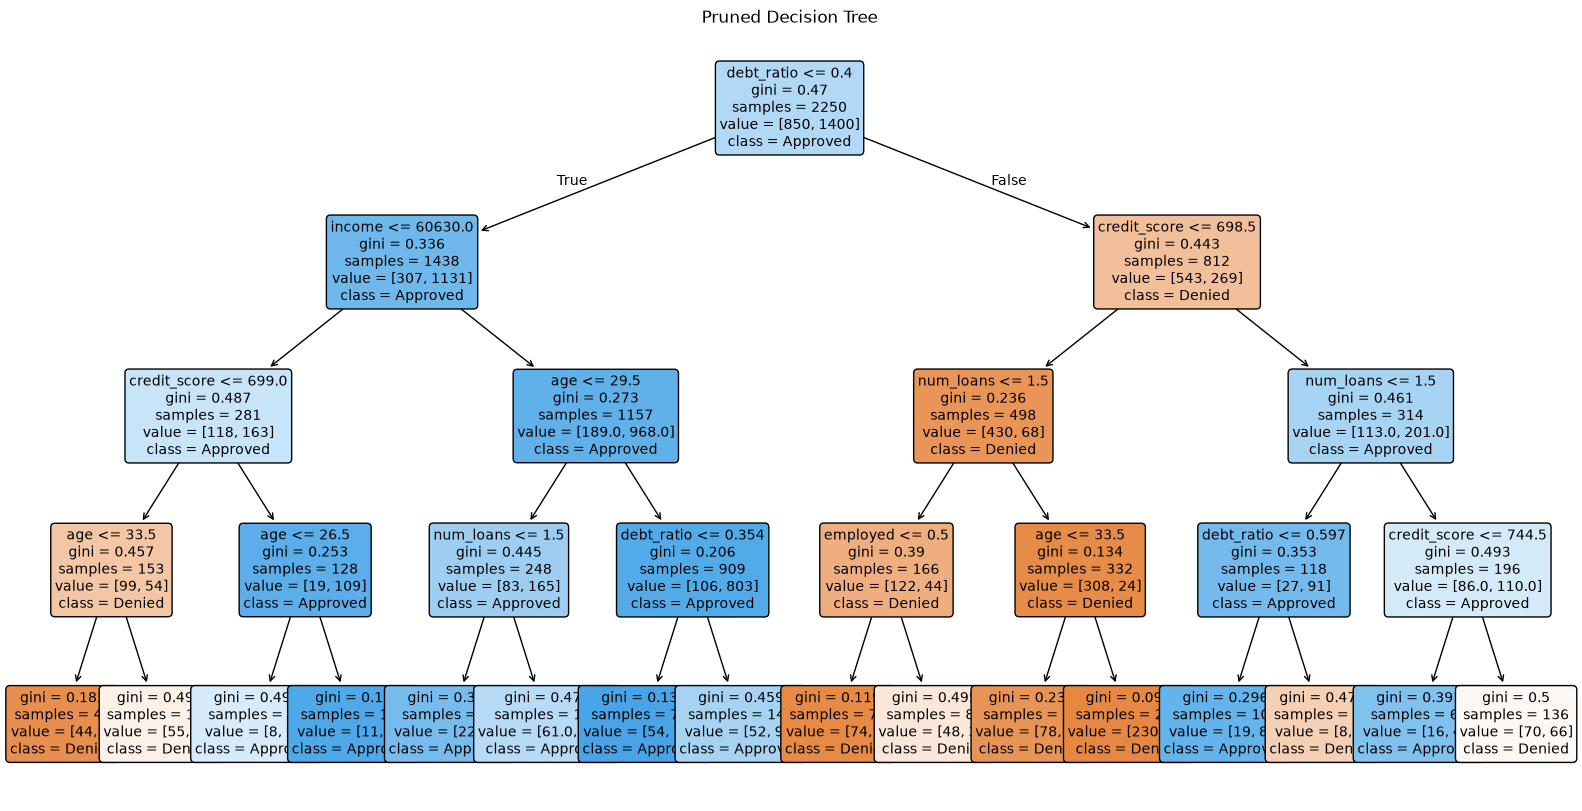

In [32]:
tree_pruned = DecisionTreeClassifier(max_depth=4, min_samples_leaf=5, random_state=42)
tree_pruned.fit(X_train, y_train)

train_acc = tree_pruned.score(X_train, y_train)
test_acc = tree_pruned.score(X_test, y_test)
print(f"depth: {tree_pruned.get_depth()}, leaves: {tree_pruned.get_n_leaves()}")
print(f"train accuracy: {train_acc:.3f}")
print(f"test accuracy : {test_acc:.3f}")

plt.figure(figsize=(20, 10))

plot_tree(
    tree_pruned,
    feature_names=X.columns,
    class_names=["Denied", "Approved"],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Pruned Decision Tree")
plt.show()

##### **==> 1. If the debt ratio is 0.40 or less, income is 60,630 or less, and credit score is 699 or less, then the model predicts loan denied.**

##### **==> 2. If the debt ratio is 0.40 or less, income is 60,630 or less, and credit score is above 699, then the model predicts loan approved.**

##### **==> 3. If the debt ratio is 0.40 or less and income is above 60,630, then the model predicts loan approved.**

## TASK 04 - Rank the features with feature_importance_
 

#### Print feature_importance_ for your pruned tree as a sorted bar chart.
#### Explain in one to two sentences which feature drives approval most and why the others matter less.
#### Sanity-check: do the two top features match the salience you saw at the root of the tree?

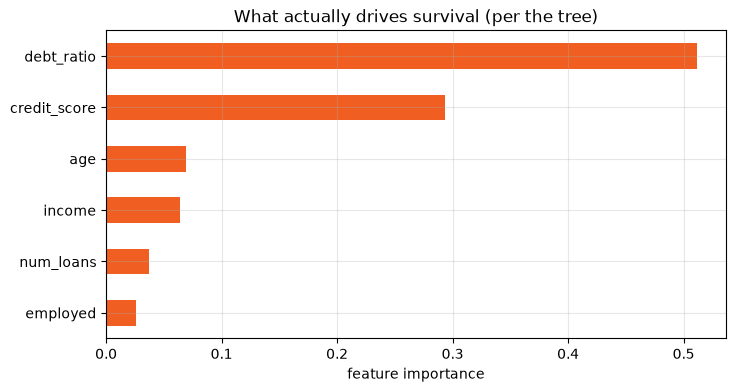

employed        0.026
num_loans       0.037
income          0.064
age             0.069
credit_score    0.294
debt_ratio      0.511
dtype: float64


In [36]:
importances = pd.Series(
    tree_pruned.feature_importances_, index=X.columns
).sort_values(ascending=True)

importances.plot(kind="barh", color="#F05E22", figsize=(8, 4))
plt.xlabel("feature importance")
plt.title("What actually drives survival (per the tree)")
plt.grid(alpha=0.3)
plt.show()

print(importances.round(3))

#### **Feature Importance Interpretation**

**The **debt ratio** is the most important feature for loan approval, with a feature importance of **0.511**, followed by **credit score (0.294)**. The other features—age, income, number of loans, and employment—have lower importance because they contribute less to the tree's impurity reduction.**

**Yes, the two top features match the tree structure: **debt ratio is the root split**, and **credit score** is used in the next major branches.**

## TASK 05 - Use cross-validation and a single pipeline to tune honestly

#### Define a model (DecisionTreeClassifier(random_state=42)) and use cross_val_score over the pipeline, scanning max_depth from 1..15. Use the CV mean as the score.
#### Compare CV mean to your earlier single-split result and explain any difference.
#### Pick the depth that maximises CV, then report its held-out test accuracy once (no cherry-picking depths on the test set).

In [39]:
tree_pipe = Pipeline([
    ("tree", DecisionTreeClassifier(min_samples_leaf=5, random_state=42))
])
cv_scores={}

for depth in range(1,16):
    tree_pipe.set_params(tree__max_depth=depth)

    scores = cross_val_score(tree_pipe, X, y, cv=5)
    cv_scores[depth] = scores.mean()

for depth, score in cv_scores.items():
    print(f"depths: {depth}, mean cv score: {score:.3f}")

best_depth = max(cv_scores, key=cv_scores.get)
best_cv_score = cv_scores[best_depth]

print("\nBest depth:", best_depth)
print(f"Best CV mean: {best_cv_score:.3f}")

depths: 1, mean cv score: 0.745
depths: 2, mean cv score: 0.785
depths: 3, mean cv score: 0.799
depths: 4, mean cv score: 0.798
depths: 5, mean cv score: 0.785
depths: 6, mean cv score: 0.778
depths: 7, mean cv score: 0.772
depths: 8, mean cv score: 0.762
depths: 9, mean cv score: 0.757
depths: 10, mean cv score: 0.762
depths: 11, mean cv score: 0.761
depths: 12, mean cv score: 0.755
depths: 13, mean cv score: 0.757
depths: 14, mean cv score: 0.752
depths: 15, mean cv score: 0.751

Best depth: 3
Best CV mean: 0.799


In [40]:
# Set the selected depth
tree_pipe.set_params(tree__max_depth=best_depth)

# Fit on the complete training data
tree_pipe.fit(X_train, y_train)

# Final held-out test accuracy
final_test_acc = tree_pipe.score(X_test, y_test)

print(f"Best depth from CV: {best_depth}")
print(f"CV mean: {best_cv_score:.3f}")
print(f"Final test accuracy: {final_test_acc:.3f}")

Best depth from CV: 3
CV mean: 0.799
Final test accuracy: 0.812


##### Cross-Validation Results

5-fold CV selected **depth 3** with a mean accuracy of **0.799**.  
After fitting on the full training set, the final **test accuracy was 0.812**.

CV is more reliable than a single split because it averages performance across multiple validation folds.

## TASK 06 - Tree vs linear model: does the tree earn its place?

##### Fit a LogisticRegression on scaled features and a pruned DecisionTreeClassifier on the raw features.

##### Compare cross-validation accuracy (and, ideally, ROC-AUC via predict_proba).

##### Verdict in two sentences: for this nonlinear dataset, does the tree beat the linear model, and what did you trade for it?

In [42]:
logistic_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(random_state=42))
])

tree_pipe = Pipeline([
    ("tree", DecisionTreeClassifier(
        max_depth=3,
        min_samples_leaf=5,
        random_state=42
    ))
])

# 5-fold CV accuracy
logistic_acc = cross_val_score(
    logistic_pipe, X_train, y_train, cv=5, scoring="accuracy"
).mean()

tree_acc = cross_val_score(
    tree_pipe, X_train, y_train, cv=5, scoring="accuracy"
).mean()

print(f"Logistic Regression CV Accuracy: {logistic_acc:.3f}")
print(f"Decision Tree CV Accuracy:       {tree_acc:.3f}")

Logistic Regression CV Accuracy: 0.740
Decision Tree CV Accuracy:       0.790


In [43]:
logistic_auc = cross_val_score(
    logistic_pipe, X_train, y_train, cv=5, scoring="roc_auc"
).mean()

tree_auc = cross_val_score(
    tree_pipe, X_train, y_train, cv=5, scoring="roc_auc"
).mean()

print(f"Logistic Regression CV ROC-AUC: {logistic_auc:.3f}")
print(f"Decision Tree CV ROC-AUC:       {tree_auc:.3f}")

Logistic Regression CV ROC-AUC: 0.780
Decision Tree CV ROC-AUC:       0.824


##### Verdict

For this nonlinear dataset, the **Decision Tree performs better** than Logistic Regression, achieving a higher CV ROC-AUC of **0.824** compared with **0.780**.

The trade-off is that the tree can capture nonlinear relationships and interactions, but it is more complex and can be less stable than the simpler linear model.